# 03. Modeling — Batch 1 학습, Batch 2 평가

**목적**
- DAY 1에 정한 전략대로 모델을 만든다: 타깃 `log10(cycle_life)`, 핵심 피처 `log_var`, 선형 계열 모델.
- 모델 선택은 Batch 1 안에서만 한다. Batch 2는 모델을 확정한 뒤 한 번만 평가한다.

## 환경 설정

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')   # 저장소 최상위를 경로에 추가
from src.preprocess import load_cache
from src.features import build_features

warnings.filterwarnings('ignore')

# 재현성
SEED = 42
np.random.seed(SEED)

# 경로
PROC_DIR = '../data/processed'
FIG_DIR = '../results/figures'
RESULT_DIR = '../results'

# 그래프 설정 (한글 폰트 포함)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. 피처 표 만들기

**목적**: `src`의 파이프라인으로 119셀의 피처 표를 만들고, 학습 배치(Batch 1)와 평가 배치를 나눈다.

In [2]:
df, qdlin, vdlin = load_cache(PROC_DIR)
feat = build_features(df, qdlin)

b1 = feat[feat['batch'] == 1].reset_index(drop=True)   # 학습 배치
b2 = feat[feat['batch'] == 2].reset_index(drop=True)   # 평가 배치
b3 = feat[feat['batch'] == 3].reset_index(drop=True)   # 추가 평가 배치

print(feat.shape)
print(feat.groupby('group').size())

(119, 10)
group
Batch 1                 36
Batch 2 newstructure     9
Batch 2 일반              30
Batch 3                 44
dtype: int64


## 2. 데이터 분할

**목적**: Batch 1의 36셀을 Train과 Hold-out(Valid)으로 나눈다.

**규칙**
- **충전 정책 단위로 나눈다.** Batch 1은 정책 20가지에 정책당 1~2셀이다. 같은 정책의 두 셀이 양쪽에 나뉘면, 거의 같은 셀을 보고 맞히는 셈이 되어 검증 성능이 실제보다 좋게 나온다.
- **수명 구간별로 고르게 뽑는다.** 정책을 평균 수명 순으로 정렬해 4개마다 하나씩 Hold-out으로 보낸다. 36셀에서 무작위로 뽑으면 수명이 한쪽으로 쏠릴 수 있다.
- **수명이 가장 짧은 정책과 가장 긴 정책은 Train에 남긴다.** 정렬한 순서에서 3번째부터 뽑는다. Hold-out은 학습 범위 안의 예측을 확인하는 용도이고, 범위 밖 예측은 뒤의 외삽 점검에서 따로 확인한다.

**기대하는 결과**: Hold-out이 정책 5개, 약 9셀(25%).

In [4]:
HOLDOUT_EVERY = 4   # 정책 4개마다 하나를 Hold-out으로
HOLDOUT_START = 2   # 평균 수명 순으로 3번째 정책부터 (0부터 세어 2)


def split_by_policy(data):
    """충전 정책 단위로 Train / Hold-out을 나눈다. 정책을 평균 수명 순으로 정렬해 일정 간격으로 뽑는다."""
    order = data.groupby('policy')['cycle_life'].mean().sort_values().index
    hold_policies = set(order[HOLDOUT_START::HOLDOUT_EVERY])
    is_hold = data['policy'].isin(hold_policies)
    return data[~is_hold].reset_index(drop=True), data[is_hold].reset_index(drop=True)


train, valid = split_by_policy(b1)

print('Train:', len(train), '셀,', train['policy'].nunique(), '정책')
print('Valid:', len(valid), '셀,', valid['policy'].nunique(), '정책')
print('양쪽에 모두 있는 정책:', len(set(train['policy']) & set(valid['policy'])))
print()
print(pd.DataFrame({'Train': train['cycle_life'].describe(),
                    'Valid': valid['cycle_life'].describe()}).round(1))
print()
print('Hold-out 셀')
print(valid.sort_values('cycle_life')[['cell_id', 'policy', 'cycle_life']].to_string(index=False))

Train: 27 셀, 15 정책
Valid: 9 셀, 5 정책
양쪽에 모두 있는 정책: 0

        Train   Valid
count    27.0     9.0
mean    786.9   793.0
std     152.2   146.4
min     534.0   617.0
25%     676.5   691.0
50%     757.0   788.0
75%     870.0   876.0
max    1074.0  1054.0

Hold-out 셀
cell_id         policy  cycle_life
  b1c38   7C(40%)-3.6C       617.0
  b1c39   7C(40%)-3.6C       625.0
  b1c18   5.4C(70%)-3C       691.0
  b1c30   6C(50%)-3.6C       709.0
  b1c19   5.4C(70%)-3C       788.0
  b1c28     6C(50%)-3C       860.0
  b1c31   6C(50%)-3.6C       876.0
  b1c29     6C(50%)-3C       917.0
   b1c9 5.4C(40%)-3.6C      1054.0


**결과 해석 — 데이터 분할**

- Train 27셀(정책 15개), Hold-out 9셀(정책 5개)로 나뉘었다. Hold-out 비율은 25%다.
- 같은 정책이 양쪽에 있는 경우가 없다. 정책 단위 분할이 의도대로 적용됐다.
- 두 집합의 수명 분포가 비슷하다. 평균 786.9 / 793.0, 중앙값 757 / 788, 표준편차 152.2 / 146.4다.
- Train의 수명 범위(534~1,074)가 Batch 1 전체와 같다. Hold-out(617~1,054)은 전부 그 안에 있으므로, Hold-out 성능은 학습 범위 안의 예측 성능이다.
- Hold-out에 b1c18이 포함됐다. EDA(Q5-1)에서 초기 측정이 불안정했던 셀이다. 규칙대로 뽑힌 결과이므로 그대로 두고, Hold-out 평가에서 이 셀의 오차를 따로 확인한다.

## 3. 모델 비교 (Train 27셀, 교차검증)

**목적**: 피처 구성 2가지와 모델 3가지를 비교해 하나를 고른다.

| 구분 | 내용 |
|---|---|
| 피처 구성 | ① `log_var` ② `log_var` + `qd_slope_last` |
| 모델 | 선형 회귀, Ridge, LASSO |
| 검증 | 정책 단위 GroupKFold(5). 같은 정책의 셀은 같은 폴드에 둔다. |
| 지표 | MAPE. 예측한 `log10(수명)`을 원래 단위로 되돌린 뒤 계산한다. |

**규칙**
- 표준화는 각 폴드의 학습 부분에서만 fit한다. 파이프라인으로 묶어 처리한다.
- Ridge와 LASSO의 `alpha`는 로그 스케일로 11개 값을 탐색해 검증 MAPE가 가장 낮은 값을 쓴다.
- 검증 MAPE의 차이가 작으면 더 단순한 쪽(피처 1개, 선형 회귀)을 고른다.

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

N_SPLITS = 5
ALPHAS = np.logspace(-4, 1, 11)   # 0.0001 ~ 10
FEATURE_SETS = {
    'log_var': ['log_var'],
    'log_var + qd_slope_last': ['log_var', 'qd_slope_last'],
}


def mape(y_true_log, y_pred_log):
    """로그 타깃을 원래 단위(사이클)로 되돌린 뒤 MAPE(%)를 계산한다."""
    y, p = 10 ** np.asarray(y_true_log), 10 ** np.asarray(y_pred_log)
    return np.mean(np.abs(p - y) / y) * 100


def make_model(name, alpha=None):
    """표준화와 회귀 모델을 묶은 파이프라인을 만든다."""
    if name == 'Linear':
        reg = LinearRegression()
    elif name == 'Ridge':
        reg = Ridge(alpha=alpha)
    else:
        reg = Lasso(alpha=alpha, max_iter=100000)
    return make_pipeline(StandardScaler(), reg)


def cv_mape(data, cols, name, alpha=None):
    """정책 단위 GroupKFold로 학습 폴드 MAPE, 검증 폴드 MAPE의 평균과 표준편차를 구한다."""
    X, y, g = data[cols].values, data['log_life'].values, data['policy'].values
    tr_scores, va_scores = [], []
    for tr, va in GroupKFold(n_splits=N_SPLITS).split(X, y, g):
        m = make_model(name, alpha).fit(X[tr], y[tr])
        tr_scores.append(mape(y[tr], m.predict(X[tr])))
        va_scores.append(mape(y[va], m.predict(X[va])))
    return np.mean(tr_scores), np.mean(va_scores), np.std(va_scores)


rows = []
for fs, cols in FEATURE_SETS.items():
    for name in ['Linear', 'Ridge', 'LASSO']:
        cands = [None] if name == 'Linear' else ALPHAS
        res = [(a,) + cv_mape(train, cols, name, a) for a in cands]
        a, tr, va, sd = min(res, key=lambda r: r[2])   # 검증 MAPE가 가장 낮은 alpha
        rows.append({'피처': fs, '모델': name, 'alpha': a,
                     '학습 폴드 MAPE': tr, '검증 폴드 MAPE': va, '폴드 간 표준편차': sd})

cv_table = pd.DataFrame(rows)
print(cv_table.round(3).to_string(index=False))

                     피처     모델  alpha  학습 폴드 MAPE  검증 폴드 MAPE  폴드 간 표준편차
                log_var Linear    NaN       7.830       9.463      1.910
                log_var  Ridge  0.000       7.830       9.463      1.910
                log_var  LASSO  0.000       7.830       9.465      1.918
log_var + qd_slope_last Linear    NaN       7.661      10.188      1.806
log_var + qd_slope_last  Ridge  3.162       7.918       9.510      3.228
log_var + qd_slope_last  LASSO  0.003       7.743       9.642      2.272


**결과 해석 — 모델 비교**

- **`log_var` 하나를 쓰는 선형 회귀를 선택한다.** 검증 폴드 MAPE가 9.46%로 여섯 조합 중 가장 낮고, 가장 단순하다.
- **두 번째 피처 `qd_slope_last`는 추가하지 않는다.** 선형 회귀에 넣으면 학습 폴드 MAPE는 7.83 → 7.66으로 내려가지만 검증 폴드는 9.46 → 10.19로 올라간다. 학습 데이터에만 맞춰지는 과적합이다.
- 정규화로도 나아지지 않는다. 피처 2개에서 Ridge(`alpha` 3.16)는 9.51%, LASSO는 9.64%로 피처 1개의 결과를 넘지 못한다.
- 피처 1개에서는 Ridge와 LASSO가 탐색 범위의 가장 작은 `alpha`(0.0001)를 골랐고 결과가 선형 회귀와 같다. 정규화가 필요하지 않다.
- 여섯 조합의 차이(9.46~10.19)는 폴드 간 표준편차(1.8~3.2)보다 작다. 조합 간 우열을 확정할 수는 없으므로, 미리 정한 규칙(차이가 작으면 단순한 모델)에 따라 골랐다.
- 선택한 모델의 학습 폴드 MAPE는 7.83%, 검증 폴드 MAPE는 9.46%다. 성능 표의 Train (CV) 값은 9.46%다.

## 4. 외삽 점검 — 학습 범위 밖을 예측할 수 있는가

**목적**: Batch 2 일반 30셀은 전부 Batch 1의 최소 수명보다 짧다. 같은 상황을 Train 안에서 미리 만들어, 선형 모델과 트리 계열이 학습 범위 밖을 어떻게 예측하는지 비교한다.

**방법**
- Train 27셀에서 수명이 짧은 7셀(약 25%)을 뺀다.
- 남은 20셀로 학습하고 뺀 7셀을 예측한다.
- 선형 회귀, Random Forest, XGBoost를 같은 피처(`log_var`)로 비교한다.

**확인하려는 가설 (DAY 1)**: 트리 계열은 학습 타깃의 범위 밖 값을 출력할 수 없으므로, 뺀 셀의 수명을 학습 범위의 최솟값 이상으로만 예측할 것이다.

Random Forest와 XGBoost는 이 점검의 대조군이며 최종 모델 후보가 아니다. Hold-out은 이 단계에서 쓰지 않는다.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

N_OUT = 7            # 뺄 셀 수 (수명이 짧은 순)
cols = ['log_var']

s = train.sort_values('cycle_life').reset_index(drop=True)
out, rest = s.iloc[:N_OUT], s.iloc[N_OUT:]

print('뺀 셀의 수명:', out['cycle_life'].astype(int).tolist())
print('남긴 셀의 수명 범위:', int(rest['cycle_life'].min()), '~', int(rest['cycle_life'].max()))
print('log_var 범위 — 뺀 셀:', out['log_var'].min().round(2), '~', out['log_var'].max().round(2),
      '/ 남긴 셀:', rest['log_var'].min().round(2), '~', rest['log_var'].max().round(2))
print()

models = {
    '선형 회귀': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=SEED),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=SEED),
}

rows, preds = [], {}
for name, m in models.items():
    m.fit(rest[cols].values, rest['log_life'].values)
    p = m.predict(out[cols].values)
    preds[name] = 10 ** p
    rows.append({'모델': name,
                 '남긴 셀 MAPE': mape(rest['log_life'], m.predict(rest[cols].values)),
                 '뺀 셀 MAPE': mape(out['log_life'], p),
                 '뺀 셀 예측 최소': 10 ** p.min(),
                 '뺀 셀 예측 최대': 10 ** p.max(),
                 '평균 편향(%)': (np.mean(10 ** p / out['cycle_life'].values) - 1) * 100})

extrap = pd.DataFrame(rows)
print(extrap.round(1).to_string(index=False))

뺀 셀의 수명: [534, 559, 599, 616, 636, 648, 651]
남긴 셀의 수명 범위: 702 ~ 1074
log_var 범위 — 뺀 셀: -3.77 ~ -3.34 / 남긴 셀: -4.16 ~ -3.65

           모델  남긴 셀 MAPE  뺀 셀 MAPE  뺀 셀 예측 최소  뺀 셀 예측 최대  평균 편향(%)
        선형 회귀        8.4      12.4      615.3      779.2      12.4
Random Forest        4.3      22.6      715.4      823.8      22.6
      XGBoost        0.7      24.9      730.7      862.9      24.9


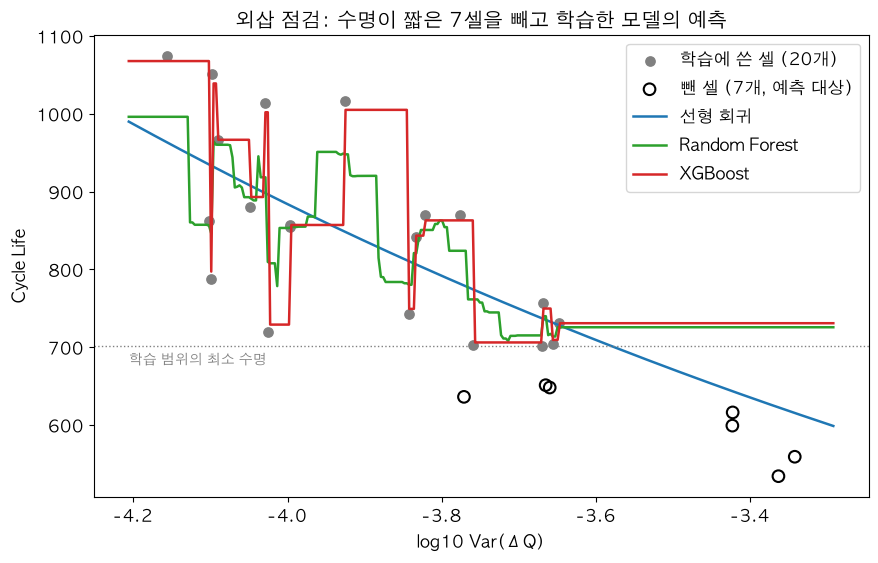

In [7]:
grid = np.linspace(train['log_var'].min() - 0.05, train['log_var'].max() + 0.05, 300).reshape(-1, 1)
line_colors = {'선형 회귀': 'tab:blue', 'Random Forest': 'tab:green', 'XGBoost': 'tab:red'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rest['log_var'], rest['cycle_life'], color='gray', s=45, label=f'학습에 쓴 셀 ({len(rest)}개)')
ax.scatter(out['log_var'], out['cycle_life'], facecolors='none', edgecolors='black', s=70,
           linewidths=1.5, label=f'뺀 셀 ({len(out)}개, 예측 대상)')
for name, m in models.items():
    ax.plot(grid, 10 ** m.predict(grid), color=line_colors[name], linewidth=1.8, label=name)
ax.axhline(rest['cycle_life'].min(), color='gray', linestyle=':', linewidth=1)
ax.text(grid.min(), rest['cycle_life'].min() - 8, '학습 범위의 최소 수명', va='top', fontsize=10, color='gray')
ax.set_xlabel('log10 Var(ΔQ)')
ax.set_ylabel('Cycle Life')
ax.set_title('외삽 점검: 수명이 짧은 7셀을 빼고 학습한 모델의 예측')
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'm1_extrapolation.png'), dpi=150, bbox_inches='tight')
plt.show()

**결과 해석 — 외삽 점검**

- **DAY 1의 가설이 확인됐다. 트리 계열은 학습 범위 밖을 예측하지 못한다.** 남긴 셀의 최소 수명이 702인데, 뺀 7셀(534~651)에 대한 예측 최소가 Random Forest 715, XGBoost 731이다. 그림에서 두 모델의 예측선은 학습 데이터가 끝나는 지점부터 수평이다.
- **선형 회귀는 범위 밖으로 연장된다.** 예측 최소가 615로 학습 범위보다 아래이고, 뺀 셀 MAPE가 12.4%로 트리 계열(22.6%, 24.9%)의 절반 수준이다.
- **학습 데이터에 잘 맞는 것과 범위 밖을 맞히는 것은 별개다.** 남긴 셀 MAPE는 XGBoost 0.7%, Random Forest 4.3%, 선형 회귀 8.4%로 순서가 반대다. 그림에서 트리 계열의 예측선은 학습 점을 하나하나 따라간다.
- 선형 회귀도 7셀을 모두 과대예측했다(+12.4%). 뺀 셀을 수명이 짧은 순으로 골랐기 때문에, 같은 `log_var`에서 직선보다 아래에 있는 셀이 뽑혀 어떤 모델이든 과대예측 쪽으로 치우친다. 뺀 셀 중 3개는 `log_var`가 학습 범위 안에 있다. 따라서 12.4%는 실제 외삽 오차보다 크게 나온 값이고, 이 점검에서 읽을 것은 모델 간의 비교다.
- **결론**: 평가 배치의 다수가 학습 범위 밖에 있는 이 과제에서는 선형 모델을 써야 한다. 3단계에서 고른 `log_var` 선형 회귀를 최종 모델로 확정한다.